# OBSERVATIONS OF NIFH GENE DATA BASED ON THE NET CDF FILE
The second dataset comes with 2 files. One is a netcdf file that is presetned here, the other is a exel file that contains several sheets. The exel file can be found in a different jupyter notebook, where it is studied and modified in depth to fit it to our use case.

In [100]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

In [101]:
temp_ds = xr.open_dataset("./nc/MarEDat20130403Diazotrophs.nc", decode_times=False)
#we can plot the netcdf file here that comes with the dataset
print(temp_ds)

<xarray.Dataset> Size: 821MB
Dimensions:         (LONGITUDE: 360, LATITUDE: 180, DEPTH: 33, TIME: 12)
Coordinates:
  * LONGITUDE       (LONGITUDE) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * LATITUDE        (LATITUDE) float32 720B -89.5 -88.5 -87.5 ... 88.5 89.62
  * DEPTH           (DEPTH) float32 132B 0.0 10.0 20.0 ... 4.5e+03 5e+03 5.5e+03
  * TIME            (TIME) float32 48B 1.314e+06 3.942e+06 ... 3.022e+07
Data variables:
    OBSERVATIONS    (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    ABUNDANCE       (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    BIOMASS         (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    nifHbiom        (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_OBS    (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_ABUND  (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_BIOM   (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_nifH   (TIME, DEPTH, LATITUDE, LO

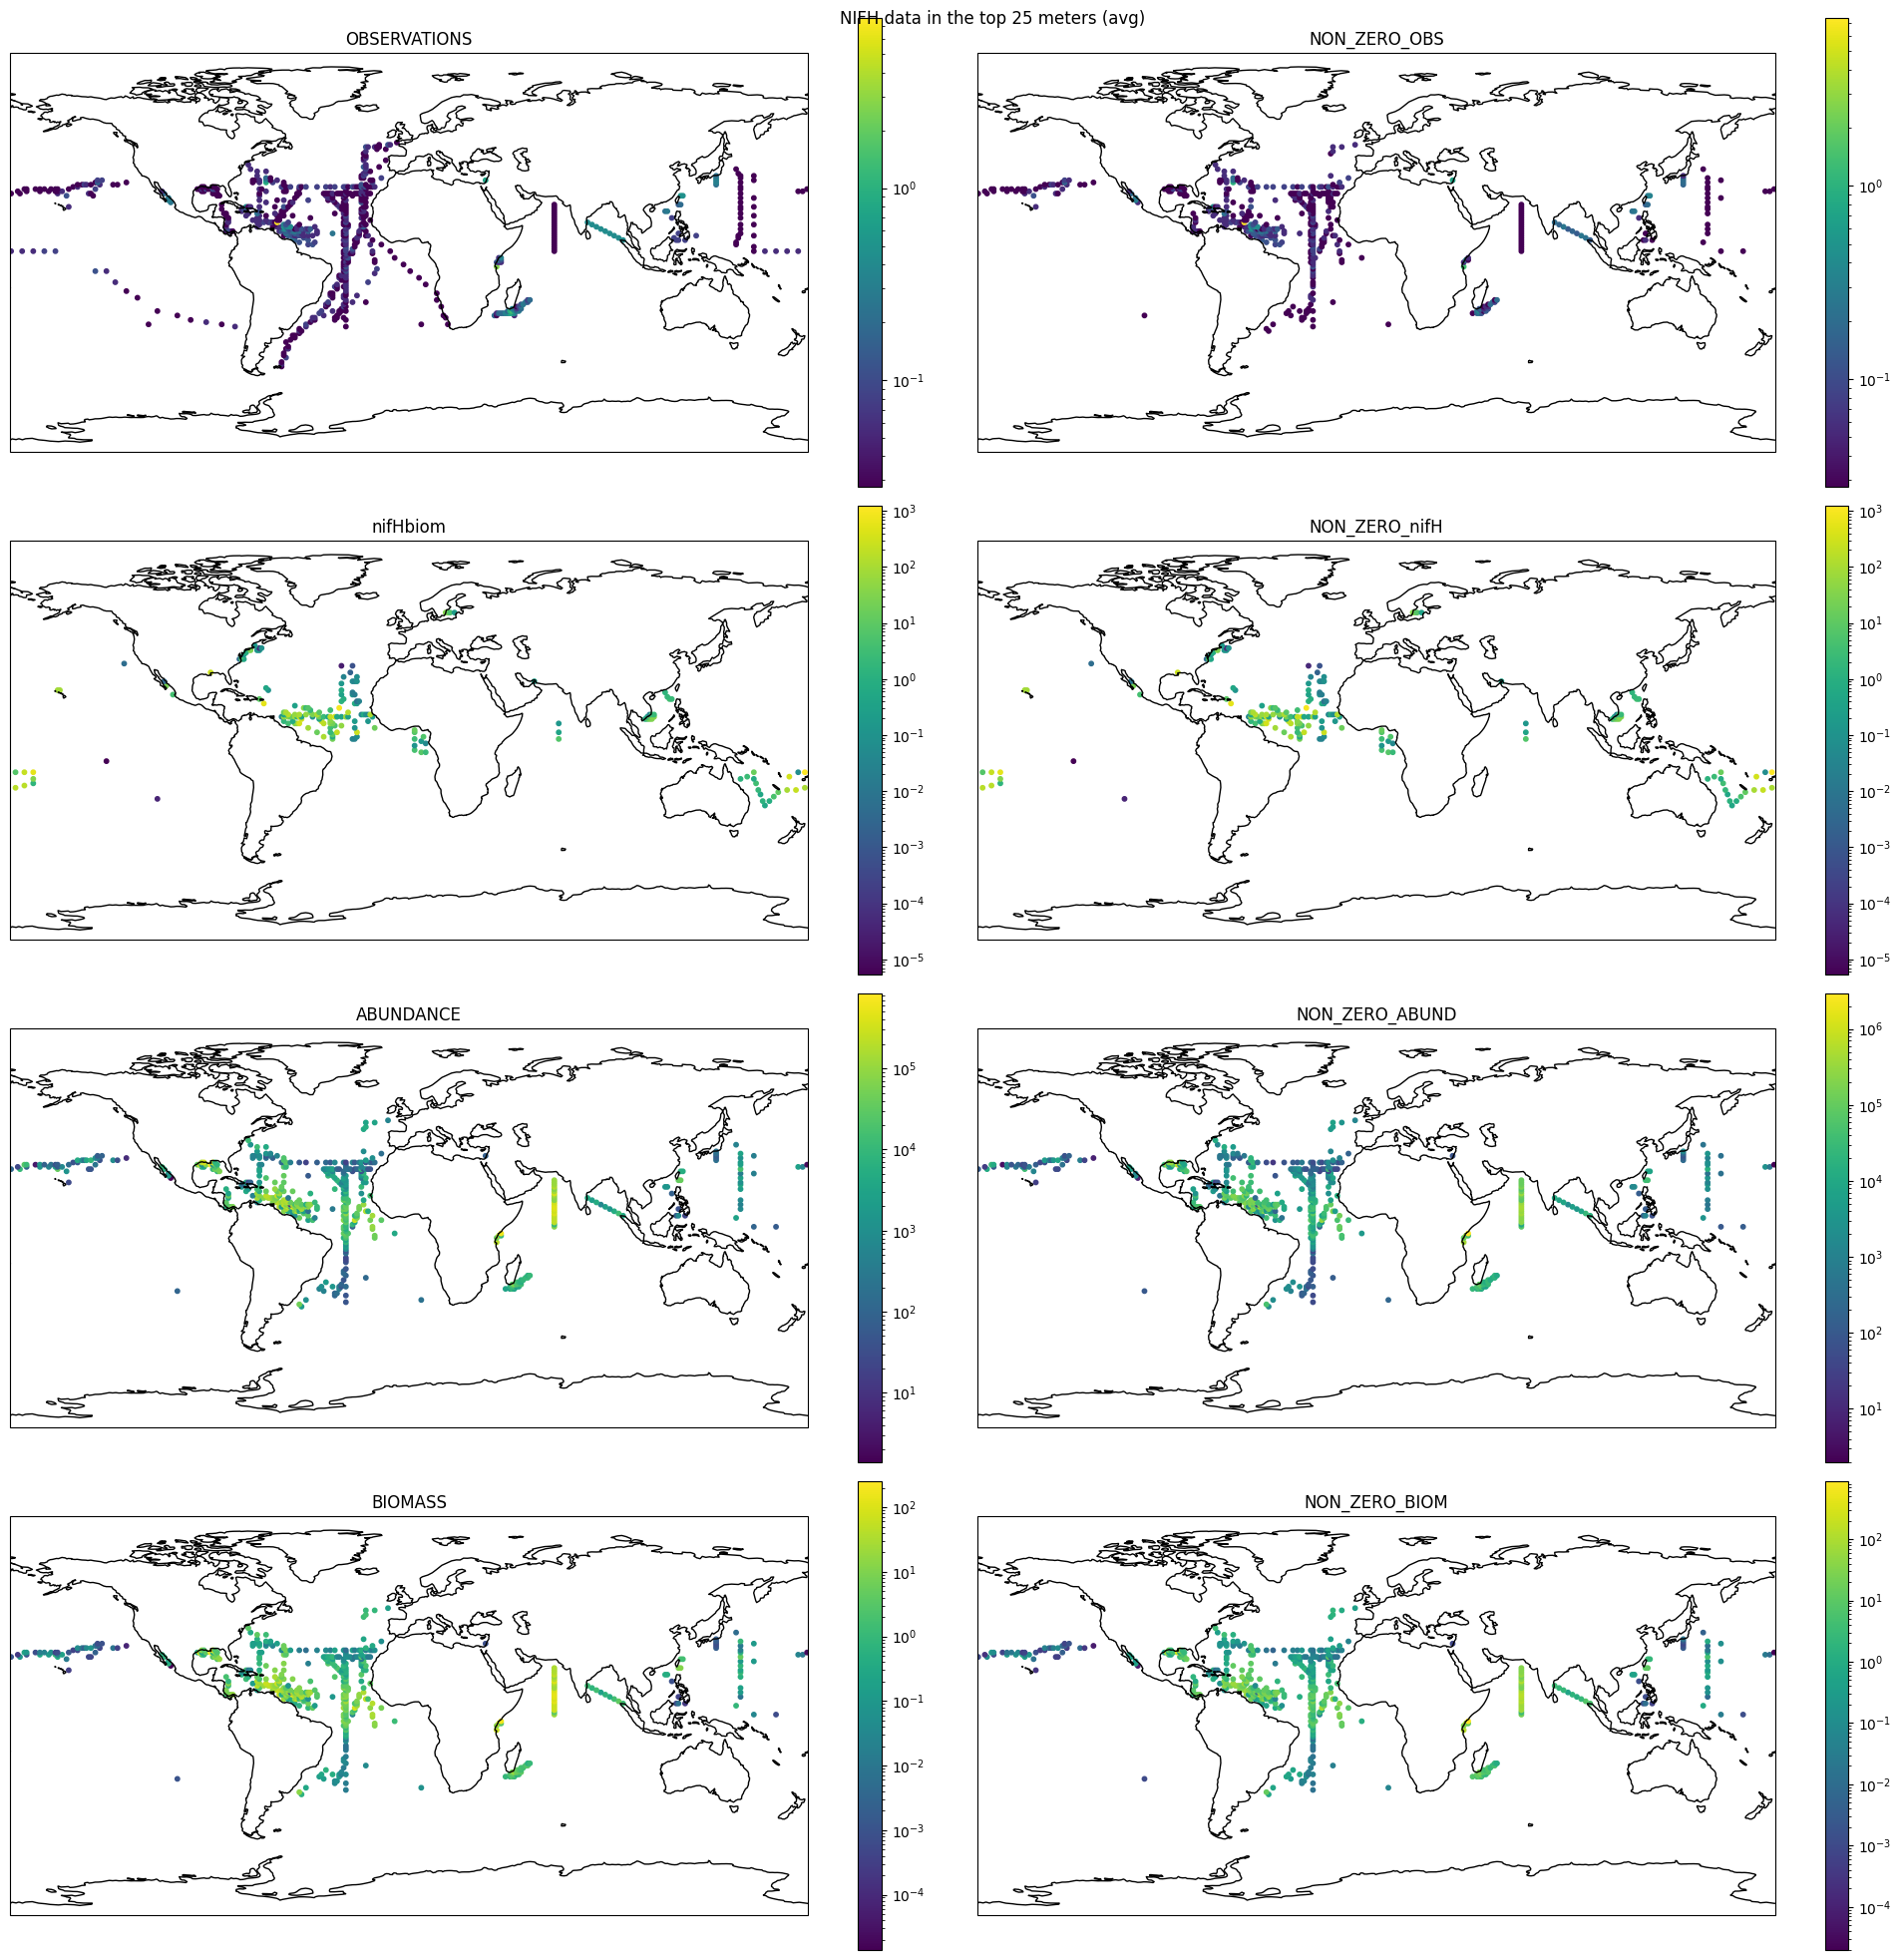

In [102]:
import matplotlib.pyplot as plt
import numpy as np

#dataset is loaded
temp_ds = xr.open_dataset("./nc/MarEDat20130403Diazotrophs.nc", decode_times=False)

#we want several subplots within a larger one and a map as the background
figure, axis = plt.subplots(4, 2, figsize=(20, 20), subplot_kw={"projection": ccrs.PlateCarree()})
axes = axis.flatten()
features = ["OBSERVATIONS","NON_ZERO_OBS","nifHbiom","NON_ZERO_nifH","ABUNDANCE","NON_ZERO_ABUND","BIOMASS","NON_ZERO_BIOM"]

for i, feature in enumerate(features):
    # Average over the top 0–25m depth and time wise
    avg = temp_ds[feature].sel(DEPTH=slice(0, 25)).mean(dim=['DEPTH',"TIME"])

    #coordinates and values
    lon, lat = np.meshgrid(temp_ds['LONGITUDE'].values, temp_ds['LATITUDE'].values)
    values = avg.values

    #data is flattened before plotting
    lon_flat = lon.flatten()
    lat_flat = lat.flatten()
    val_flat = values.flatten()

    # Remove NaNs and FillValues (e.g. 1e+35)
    mask = ~np.isnan(val_flat) & (val_flat < 1e10)  # remove 1e35 dummy values
    lon_flat = lon_flat[mask]
    lat_flat = lat_flat[mask]
    val_flat = val_flat[mask]

    #we plot the data on the subplots
    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    col = ax.scatter(lon_flat, lat_flat, c=val_flat, cmap='viridis', s=10,norm=matplotlib.colors.LogNorm())
    ax.set_title(feature)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-180,180)
    ax.set_ylim(-90,90)
    ax.set_title(feature)
    figure.colorbar(col, ax=ax, orientation='vertical')

# Add title and layout
figure.suptitle("NIFH data in the top 25 meters (avg)")
plt.tight_layout()
plt.show()
